<a href="https://colab.research.google.com/github/NazHub1993/LinearRegression_VS_SVR/blob/main/GaussianNB_VS_SVC(Dry%20Bean%20Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dry Bean Classification — GaussianNB vs SVC with PCA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.pipeline import Pipeline

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joebeachcapital/dry-beans")

print("Path to dataset files:", path)

100%|██████████| 4.53M/4.53M [00:01<00:00, 3.60MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/joebeachcapital/dry-beans/versions/1


In [ ]:
import os

# See what files are in the downloaded folder
print(os.listdir(path))

['DryBeanDataset']


In [ ]:
print(os.listdir(os.path.join(path, 'DryBeanDataset')))

['Dry_Bean_Dataset.txt', 'Dry_Bean_Dataset.xlsx', 'Dry_Bean_Dataset.arff']


In [13]:
df = pd.read_excel(os.path.join(path, 'DryBeanDataset', 'Dry_Bean_Dataset.xlsx'))
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [14]:
df.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [15]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [16]:
df.dtypes

,0
Area,int64
Perimeter,float64
MajorAxisLength,float64
MinorAxisLength,float64
AspectRation,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Solidity,float64


In [17]:
df.Class.value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


#So there are 7 classes of beans

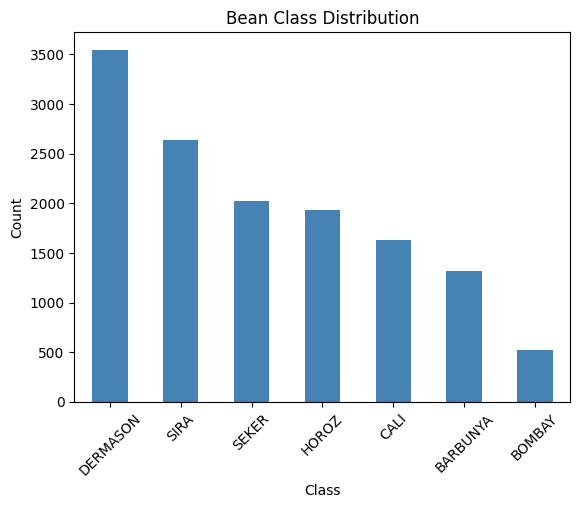

In [18]:
df['Class'].value_counts().plot(kind='bar',color='steelblue')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title("Bean Class Distribution")
plt.xticks(rotation=45)
plt.show()

#Let's talk about Feature Correlation now.

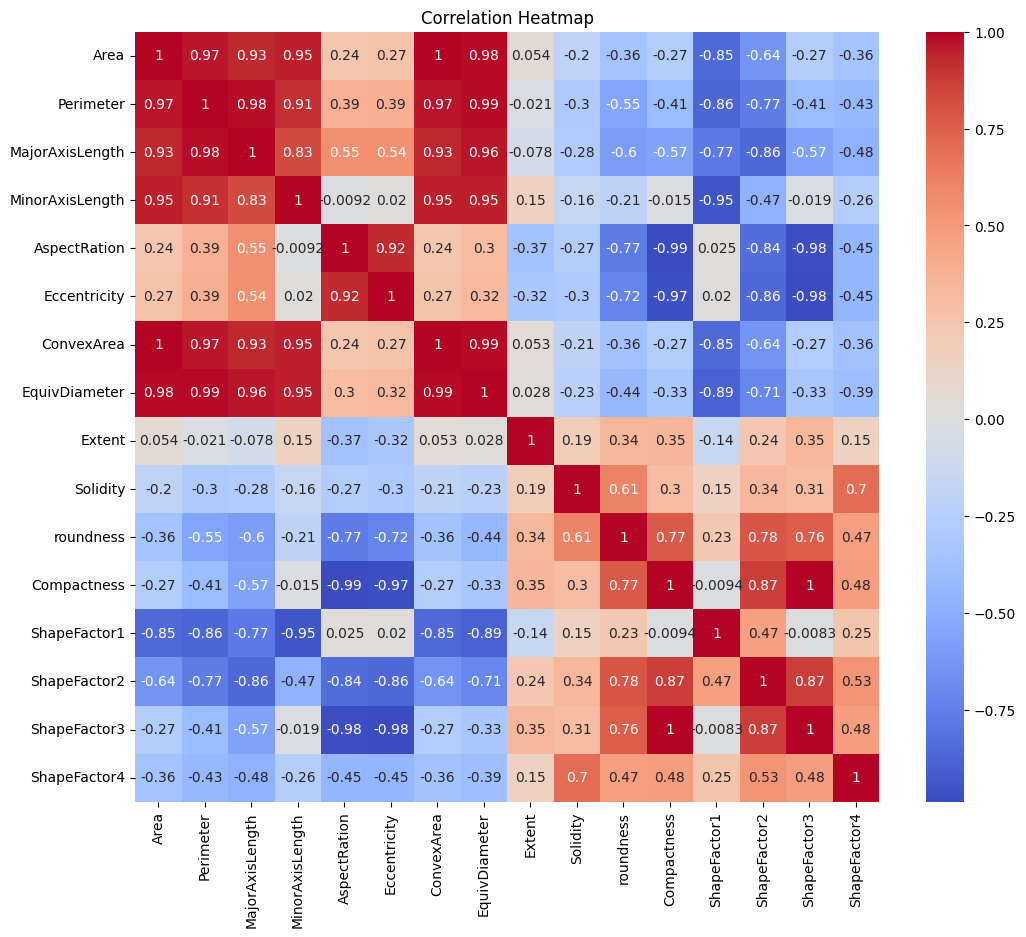

In [20]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop('Class',axis=1).corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Time for Preprocessing

In [22]:
X=df.drop('Class',axis=1)
Y=df['Class']

#label encoding is done because it is not possible to predict string as output
le=LabelEncoder()
Y=le.fit_transform(Y)

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

#Because the features are continuous features it is required to scale for PCA
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)




#Before applying PCA how to know how many components should be applied?

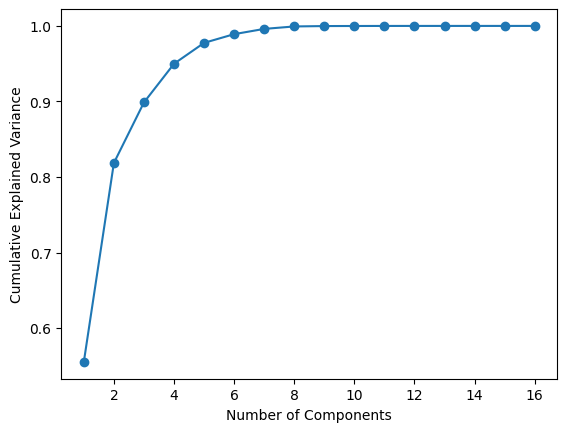

In [23]:
pca_full=PCA()
pca_full.fit(x_train_scaled)

explained=np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1,len(explained)+1),explained,marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()


In [24]:
n_comp=np.argmax(explained>=0.95)+1
print("Principle Components Needed",n_comp)

Principle Components Needed 5


In [25]:
pca=PCA(n_components=n_comp)
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

#So applying PCA is done

#Gaussian NB Pipeline

In [28]:
gnb_pipeline=Pipeline([
    ('pca',PCA(n_components=n_comp)),
    ('gnb',GaussianNB())
])

gnb_params={
    'gnb__var_smoothing':[1e-9, 1e-8, 1e-7]
}

gnb_grid=RandomizedSearchCV(
    estimator=gnb_pipeline,
    param_distributions=gnb_params,
    cv=5,
    scoring=['accuracy'],
    refit='accuracy',
    n_jobs=-1
)
gnb_grid.fit(x_train_scaled,y_train)

print("Gaussian NB Parameters: ",gnb_grid.best_params_)
print("Gaussian NB score: ",gnb_grid.best_score_)


Gaussian NB Parameters:  {'gnb__var_smoothing': 1e-09}
Gaussian NB score:  0.8942873424603913


In [30]:
from sklearn.model_selection import cross_val_score

In [36]:
gnb=gnb_grid.best_estimator_
gnb_pred=gnb.predict(x_test_scaled)

scores=cross_val_score(gnb,x_train_scaled,y_train,cv=5,scoring='accuracy')
print("Cross Validation Scores (Train): ",scores.mean())

scores=cross_val_score(gnb,x_test_scaled,y_test,cv=5,scoring='accuracy')
print("Cross Validation Scores (Test): ",scores.mean())

print("classification-report",classification_report(y_test,gnb_pred))


Cross Validation Scores (Train):  0.8942873424603913
Cross Validation Scores (Test):  0.900846600107933
classification-report               precision    recall  f1-score   support

           0       0.92      0.90      0.91       261
           1       1.00      1.00      1.00       117
           2       0.92      0.92      0.92       317
           3       0.88      0.88      0.88       671
           4       0.92      0.95      0.93       408
           5       0.97      0.93      0.95       413
           6       0.81      0.84      0.83       536

    accuracy                           0.90      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.90      0.90      0.90      2723



<Axes: >

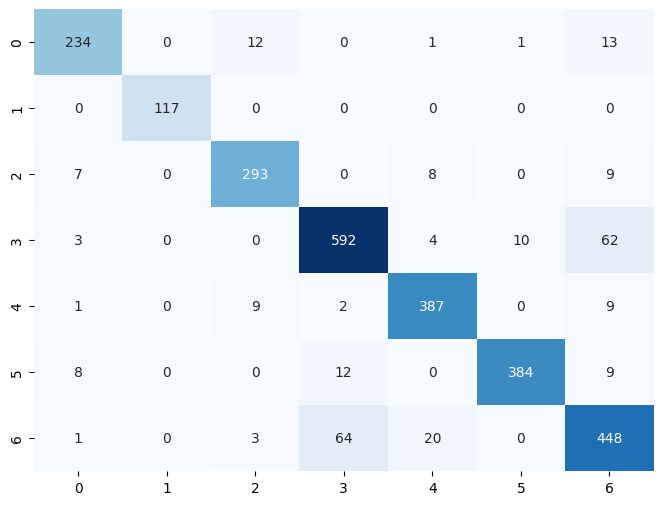

In [42]:
cm=confusion_matrix(y_test,gnb_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False)

#Let's Go for SVC now!!

In [39]:
svc_pipeline=Pipeline([
    ('pca',PCA(n_components=n_comp)),
    ('svc',SVC())
])

param_grid={
    'svc__C':[0.1,1,10,100],
    'svc__gamma':['scale','auto'],
     'svc__kernel':['rbf','linear']
}

svc_grid=RandomizedSearchCV(
    estimator=svc_pipeline,
    param_distributions=param_grid,
    cv=5,
    scoring='accuracy'
)

svc_grid.fit(x_train_scaled,y_train)

print("Best Parameters for SVC: ",svc_grid.best_params_)
print("Best score for SVC: ",svc_grid.best_score_)


Best Parameters for SVC:  {'svc__kernel': 'rbf', 'svc__gamma': 'auto', 'svc__C': 1}
Best score for SVC:  0.9289127125432299


In [41]:
svc=svc_grid.best_estimator_
svc_pred=svc.predict(x_test_scaled)

scores=cross_val_score(svc,x_train_scaled,y_train,cv=5,scoring='accuracy')
print("Cross Validation Score(Train): ",scores.mean())

scores=cross_val_score(svc,x_test_scaled,y_test,cv=5,scoring='accuracy')
print("Cross Validation Score(Test): ",scores.mean())

print("classification-report",classification_report(y_test,svc_pred))

Cross Validation Score(Train):  0.9289127125432299
Cross Validation Score(Test):  0.9228797895304911
classification-report               precision    recall  f1-score   support

           0       0.93      0.91      0.92       261
           1       1.00      1.00      1.00       117
           2       0.94      0.94      0.94       317
           3       0.91      0.93      0.92       671
           4       0.97      0.96      0.97       408
           5       0.97      0.95      0.96       413
           6       0.88      0.89      0.88       536

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



<Axes: >

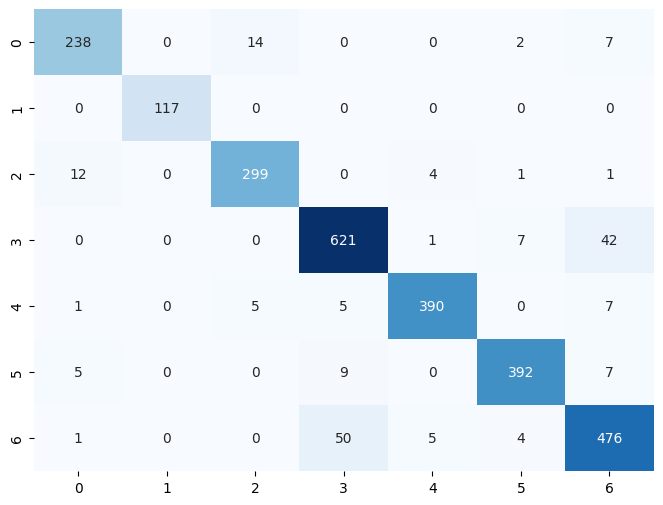

In [43]:
cm=confusion_matrix(y_test,svc_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False)

In [46]:
results = {
    'Model': ['Gaussian Naive Bayes', 'SVC'],
    'CV Accuracy': [round(gnb_grid.best_score_, 4), round(svc_grid.best_score_, 4)],
    'Test Accuracy': [round(accuracy_score(y_test, gnb_pred), 4),
                      round(accuracy_score(y_test, svc_pred), 4)]
}

results_df = pd.DataFrame(results)
print(results_df)

                  Model  CV Accuracy  Test Accuracy
0  Gaussian Naive Bayes       0.8943         0.9016
1                   SVC       0.9289         0.9302


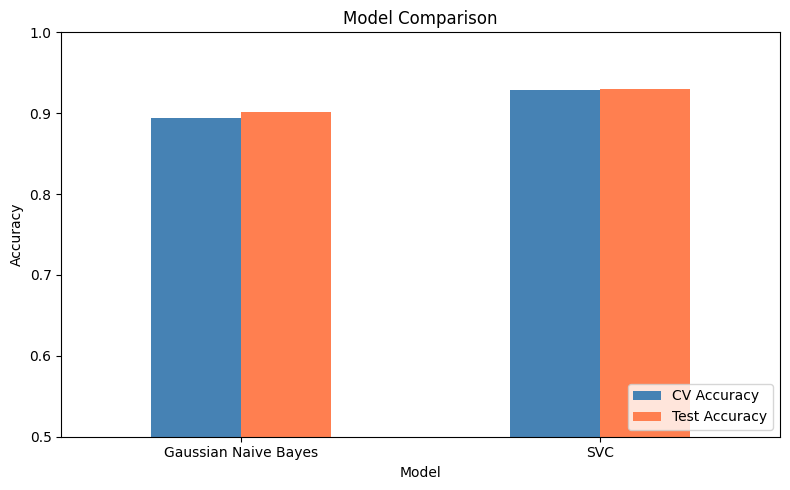

In [47]:
results_df.set_index('Model').plot(kind='bar', figsize=(8, 5), color=['steelblue', 'coral'])
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#So we can clearly see that SVC outperforms GAUSSIAN_NB here because Features did not have enough Normal Distribution